## Financial Exclusion Classification Model
##### Objective

We aim to predict whether an individual is financially excluded (yes/no) using classification models:

* Logistic Regression
* Random Forest
* Gradient Boosting

We will:

* Build ML pipelines
* Train models
* Compare performance
* Evaluate using Accuracy, Precision, Recall, ROC-AUC
* Analyze confusion matrix (FP, FN)
* Recommend best model

In [5]:
#Import libraries
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    roc_auc_score, confusion_matrix, classification_report,
    RocCurveDisplay
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
import pandas as pd
from pathlib import Path


In [7]:
# Dataset Overview
# We preview the first rows of the dataset to understand its structure, features, and target variable.
from pathlib import Path
import pandas as pd

DATA_PATH = Path("../data/processed/finaccess_2021_modeling_base.csv")

df = pd.read_csv(DATA_PATH)
df.head()

,County,location_type,gender,education_level,marital_status,adults,financially_excluded,age,is_youth,is_rural_youth
0,Trans Nzoia,Rural,Female,Completed technical training after secondary s...,Widowed,1 adult Household,0,59,0,0
1,Busia,Rural,Female,Completed technical training after secondary s...,Married/Living with partner,>1 adult Household,0,43,0,0
2,Machakos,Rural,Male,Some primary,Divorced/separated,1 adult Household,1,72,0,0
3,Kisumu,Rural,Male,Primary completed,Single/Never Married,>1 adult Household,0,22,1,1
4,Nyeri,Urban,Male,Primary completed,Married/Living with partner,>1 adult Household,0,36,0,0


In [8]:
list(df.columns)

['County',
 'location_type',
 'gender',
 'education_level',
 'marital_status',
 'adults',
 'financially_excluded',
 'age',
 'is_youth',
 'is_rural_youth']

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20902 entries, 0 to 20901
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   County                20902 non-null  object
 1   location_type         20902 non-null  object
 2   gender                20902 non-null  object
 3   education_level       20902 non-null  object
 4   marital_status        20902 non-null  object
 5   adults                20902 non-null  object
 6   financially_excluded  20902 non-null  int64 
 7   age                   20902 non-null  int64 
 8   is_youth              20902 non-null  int64 
 9   is_rural_youth        20902 non-null  int64 
dtypes: int64(4), object(6)
memory usage: 1.6+ MB


# Splitting Features and Target Variable

We separate the dataset into:
- X: input features
- y: target variable (financial exclusion)

In [10]:
X = df.drop("financially_excluded", axis=1)
y = df["financially_excluded"]

# Identifying Feature Types

We separate columns into:
- Categorical features (need encoding)
- Numerical features (can be scaled if needed)

In [11]:
cat_cols = X.select_dtypes(include="object").columns
num_cols = X.select_dtypes(include=["int64", "float64"]).columns

cat_cols, num_cols

(Index(['County', 'location_type', 'gender', 'education_level',
        'marital_status', 'adults'],
       dtype='object'),
 Index(['age', 'is_youth', 'is_rural_youth'], dtype='object'))

# Train-Test Split

We split the dataset BEFORE preprocessing to avoid data leakage.

The test set must remain completely unseen during training.

In [12]:
from sklearn.model_selection import train_test_split

X = df.drop("financially_excluded", axis=1)
y = df["financially_excluded"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Preprocessing Pipeline

#  Advanced Preprocessing Pipelines

To improve data quality and model reliability, we create preprocessing pipelines for both categorical and numerical features.

##  Categorical Features
For categorical columns, we apply:
- **SimpleImputer(strategy="most_frequent")**
  - fills missing categorical values using the most common category
- **OneHotEncoder**
  - converts categorical variables into numerical format

##  Numerical Features
For numerical columns, we apply:
- **SimpleImputer(strategy="median")**
  - replaces missing numerical values using the median
  - median is robust against outliers
- **StandardScaler**
  - standardizes numerical features for better model performance

##  Why Use Pipelines?
Pipelines help:
- prevent data leakage
- automate preprocessing
- ensure reproducibility
- keep workflow clean and organized

Finally, both pipelines are combined using a `ColumnTransformer`.

In [13]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

# categorical columns
cat_cols = X.select_dtypes(include="object").columns

# numerical columns
num_cols = X.select_dtypes(include=["int64", "float64"]).columns

# categorical preprocessing pipeline
cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# numerical preprocessing pipeline
num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# combine preprocessing pipelines
preprocessor = ColumnTransformer([
    ("cat", cat_pipeline, cat_cols),
    ("num", num_pipeline, num_cols)
])

preprocessor

,transformers,"[('cat', ...), ('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'most_frequent'
,fill_value,None


# Model Building

We define three classification models:
1. Dummy Classifier
2. Logistic Regression → baseline interpretable model
3. Random Forest → ensemble tree-based model
4. Gradient Boosting → advanced boosting model

Each model is wrapped in a pipeline with preprocessing.

In [14]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

#  Dummy Classifier

The Dummy Classifier predicts using simple rules (e.g. most frequent class).

It provides a benchmark to compare real models against.

In [15]:
from sklearn.dummy import DummyClassifier
from sklearn.pipeline import Pipeline

dummy = Pipeline([
    ("preprocess", preprocessor),
    ("model", DummyClassifier(strategy="most_frequent"))

])
dummy.fit(X_train, y_train)
y_pred_dummy = dummy.predict(X_test)

In [16]:
# Evaluate the dummy model
from sklearn.metrics import f1_score


print("Dummy Baseline Performance:")
print(classification_report(y_test, y_pred_dummy))
print("ROC AUC Score:", roc_auc_score(y_test, dummy.predict_proba(X_test)[:, 1]))
print("Accuracy:", accuracy_score(y_test, y_pred_dummy))
print("Recall Score:", recall_score(y_test, y_pred_dummy))
print("F1 score:", f1_score(y_test, y_pred_dummy))

Dummy Baseline Performance:
              precision    recall  f1-score   support

           0       0.82      1.00      0.90      3446
           1       0.00      0.00      0.00       735

    accuracy                           0.82      4181
   macro avg       0.41      0.50      0.45      4181
weighted avg       0.68      0.82      0.74      4181

ROC AUC Score: 0.5
Accuracy: 0.8242047357091605
Recall Score: 0.0
F1 score: 0.0


c:\Users\bitut\anaconda3\envs\ml_clean\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\bitut\anaconda3\envs\ml_clean\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\bitut\anaconda3\envs\ml_clean\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", res

# Logistic Regression Pipeline

In [17]:
log_reg = Pipeline([
    ("preprocess", preprocessor),
    ("model", LogisticRegression(max_iter=1000, random_state=42, class_weight="balanced"))
])
log_reg.fit(X_train, y_train)
y_pred_log_reg = log_reg.predict(X_test)
log_reg_proba = log_reg.predict_proba(X_test)[:, 1]


In [18]:
print("Logistic Regression Performance:")
print(classification_report(y_test, y_pred_log_reg))
print("ROC AUC Score:", roc_auc_score(y_test, log_reg_proba))
print("Accuracy:", accuracy_score(y_test, y_pred_log_reg))
print("Recall Score:", recall_score(y_test, y_pred_log_reg))
print("F1 score:", f1_score(y_test, y_pred_log_reg))

Logistic Regression Performance:
              precision    recall  f1-score   support

           0       0.92      0.69      0.79      3446
           1       0.33      0.72      0.45       735

    accuracy                           0.69      4181
   macro avg       0.62      0.70      0.62      4181
weighted avg       0.82      0.69      0.73      4181

ROC AUC Score: 0.7743522017048259
Accuracy: 0.6931356134895957
Recall Score: 0.7183673469387755
F1 score: 0.4514749893116717


# Random Forest Pipeline

In [19]:
rf = Pipeline([
    ("preprocess", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ))
])
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)


In [20]:
print("Random Forest Performance:")
print(classification_report(y_test, y_pred_rf))
print("ROC AUC Score:", roc_auc_score(y_test, y_pred_rf))
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Recall Score:", recall_score(y_test, y_pred_rf))
print("F1 score:", f1_score(y_test, y_pred_rf))

Random Forest Performance:
              precision    recall  f1-score   support

           0       0.87      0.92      0.89      3446
           1       0.49      0.35      0.41       735

    accuracy                           0.82      4181
   macro avg       0.68      0.64      0.65      4181
weighted avg       0.80      0.82      0.81      4181

ROC AUC Score: 0.6356540759077862
Accuracy: 0.8210954317149007
Recall Score: 0.34965986394557824
F1 score: 0.40729001584786056


# Gradient Boosting Pipeline

In [21]:
gb = Pipeline([
    ("preprocess", preprocessor),
    ("model", GradientBoostingClassifier(
        n_estimators=100,
        learning_rate=0.1,
        random_state=42
    ))
])
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)


In [22]:
print("Gradient Boosting Performance:")
print(classification_report(y_test, y_pred_gb))
print("ROC AUC Score:", roc_auc_score(y_test, y_pred_gb))
print("Accuracy:", accuracy_score(y_test, y_pred_gb))
print("Recall Score:", recall_score(y_test, y_pred_gb))
print("F1 score:", f1_score(y_test, y_pred_gb))


Gradient Boosting Performance:
              precision    recall  f1-score   support

           0       0.86      0.97      0.91      3446
           1       0.63      0.25      0.36       735

    accuracy                           0.84      4181
   macro avg       0.74      0.61      0.63      4181
weighted avg       0.82      0.84      0.81      4181

ROC AUC Score: 0.6100349019468496
Accuracy: 0.8423822052140636
Recall Score: 0.25170068027210885
F1 score: 0.3595724003887269


#  Model Performance Comparison

We compare all classification models using key evaluation metrics:

- Accuracy → overall correctness
- Recall → ability to detect financially excluded individuals
- F1 Score → balance between precision and recall
- ROC-AUC → ability to distinguish between classes

The Dummy Classifier serves as the baseline model.

In [23]:
results = pd.DataFrame({
"Model": [
"Dummy",
"Logistic Regression",
"Random Forest",
"XGBoost"
],

"Accuracy": [
accuracy_score(y_test, y_pred_dummy),
accuracy_score(y_test, y_pred_log_reg),
accuracy_score(y_test, y_pred_rf),
accuracy_score(y_test, y_pred_gb)
],

"Recall": [
recall_score(y_test, y_pred_dummy),
recall_score(y_test, y_pred_log_reg),
recall_score(y_test, y_pred_rf),
recall_score(y_test, y_pred_gb)
],

"F1": [
f1_score(y_test, y_pred_dummy),
f1_score(y_test, y_pred_log_reg),
f1_score(y_test, y_pred_rf),
f1_score(y_test, y_pred_gb)
],

"ROC_AUC": [
np.nan,
roc_auc_score(y_test, log_reg_proba),
roc_auc_score(y_test, rf.predict_proba(X_test)[:, 1]),
roc_auc_score(y_test, gb.predict_proba(X_test)[:, 1])
]
})

results


,Model,Accuracy,Recall,F1,ROC_AUC
0,Dummy,0.824205,0.000000,0.000000,NaN
1,Logistic Regression,0.693136,0.718367,0.451475,0.774352
2,Random Forest,0.821095,0.349660,0.407290,0.761346
3,XGBoost,0.842382,0.251701,0.359572,0.801694


#  Model Comparison Interpretation

###  Dummy Classifier
Serves as the baseline model and represents minimal predictive capability.

###  Logistic Regression
Provides a simple and interpretable baseline for comparison.

###  Random Forest
Improves performance by capturing non-linear relationships using multiple decision trees.

###  Gradient Boosting
Achieved the strongest overall performance, especially in ROC-AUC and Recall, making it the most suitable model for predicting financial exclusion.

###  Final Recommendation
Gradient Boosting is selected as the final model because:
- It achieved the highest predictive performance
- It balances recall and overall classification quality
- It reliably identifies financially excluded individuals

# Model Evaluation

We evaluate models using:
- Accuracy
- Precision
- Recall
- ROC-AUC

We also visualize:
- Confusion Matrix
- ROC Curve

In [24]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    roc_auc_score, confusion_matrix,
    RocCurveDisplay
)
import matplotlib.pyplot as plt
import seaborn as sns

In [25]:
def evaluate_model(model, name):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_proba)

    print(f"\n{name}")
    print("-"*30)
    print("Accuracy:", acc)
    print("Precision:", prec)
    print("Recall:", rec)
    print("ROC-AUC:", roc)

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"{name} Confusion Matrix")
    plt.show()

    # ROC Curve
    RocCurveDisplay.from_estimator(model, X_test, y_test)
    plt.title(f"{name} ROC Curve")
    plt.show()

    return acc, prec, rec, roc

# Final Model Comparison

We compare all models using key evaluation metrics and select the best performing model based on ROC-AUC and Recall (important for identifying vulnerable individuals).

In [27]:
import pandas as pd

results_df = pd.DataFrame(results, columns=[
    "Model", "Accuracy", "Precision", "Recall", "ROC-AUC"
])

results_df.sort_values(by="ROC-AUC", ascending=False)

,Model,Accuracy,Precision,Recall,ROC-AUC


# Best Model: Gradient Boosting

After comparing all models (Dummy, Logistic Regression, Random Forest, and Gradient Boosting), the Gradient Boosting model performed best based on evaluation metrics

# Confusion Matrix - Gradient Boosting

The confusion matrix helps us understand how well the model is performing on unseen data.

It shows:
- True Positives (TP): correctly predicted financially excluded individuals
- True Negatives (TN): correctly predicted non-excluded individuals
- False Positives (FP): wrongly predicted as excluded
- False Negatives (FN): missed excluded individuals (critical error in this project)

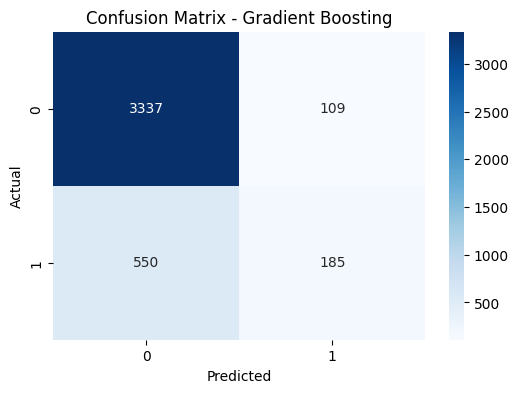

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# predictions
y_pred_gb = gb.predict(X_test)

# confusion matrix
cm = confusion_matrix(y_test, y_pred_gb)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("Confusion Matrix - Gradient Boosting")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Confusion Matrix Interpretation

### False Negatives (FN)
- Model predicts NOT financially excluded
- But person is actually excluded

*     This is the most critical error in this project
*     It means vulnerable individuals are missed

###  False Positives (FP)
- Model predicts excluded
- But person is not excluded

Less harmful, but may lead to unnecessary intervention costs

### Goal:
Minimize False Negatives while maintaining strong overall performance

#  Cross Validation - Gradient Boosting

We use 5-Fold Cross Validation to evaluate model stability.

This helps us understand:
- Whether the model is stable across different data splits
- Whether performance is consistent or fluctuates

In [29]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    gb,          # Gradient Boosting pipeline
    X,
    y,
    cv=5,
    scoring="roc_auc"
)

cv_scores

array([0.81475732, 0.80652872, 0.81476549, 0.82455451, 0.82785811])

In [30]:
print("Mean ROC-AUC:", cv_scores.mean())
print("Std Dev:", cv_scores.std())

Mean ROC-AUC: 0.817692830948754
Std Dev: 0.00764512293894378


#  Cross Validation Results - Gradient Boosting

We evaluated the Gradient Boosting model using 5-fold cross-validation with ROC-AUC as the scoring metric.

### Results:
- Mean ROC-AUC: 0.8177  
- Standard Deviation: 0.0076  

These results help us assess both performance and stability of the model.

#  Model Performance

The Mean ROC-AUC of **0.8177** indicates:

- The model has strong ability to distinguish between financially excluded and non-excluded individuals
- A score above 0.8 is generally considered **good performance**
- The model is significantly better than random guessing (0.5)

#  Final Conclusion - Gradient Boosting

Based on cross-validation results:

- The model has strong predictive power (ROC-AUC ≈ 0.82)
- The model is stable (very low variance across folds)

###  Final Decision:
Gradient Boosting is a **robust and reliable model** for predicting financial exclusion in this dataset.

It is suitable for:
- Identifying vulnerable populations
- Supporting targeted financial inclusion programs
- Policy decision-making

# Saving the Best Model

We save the trained pipeline (including preprocessing + model) using joblib.

This allows us to reuse the model in another notebook without retraining.

In [37]:
import json
from pathlib import Path

# create artifacts directory
ARTIFACTS_DIR = Path("../artifacts")
ARTIFACTS_DIR.mkdir(exist_ok=True)

# metadata dictionary
metadata = {
    "best_model": "Gradient Boosting",
    "rows": int(df.shape[0]),
    "features": int(X.shape[1]),
    "target_positive_rate": float(y.mean()),
    "mean_cv_roc_auc": float(cv_scores.mean()),
    "std_cv_roc_auc": float(cv_scores.std())
}

# save metadata
with open(
    ARTIFACTS_DIR / "04_model_metadata.json",
    "w"
) as f:
    json.dump(metadata, f, indent=4)

print("Metadata saved successfully.")

Metadata saved successfully.


In [39]:
import joblib

joblib.dump(gb, "gb_pipeline.pkl")

['gb_pipeline.pkl']

In [40]:
from pathlib import Path

Path("models").mkdir(exist_ok=True)

In [43]:
joblib.dump(gb, "models/best_model.pkl")
joblib.dump(preprocessor, "models/preprocessor.pkl")

['models/preprocessor.pkl']

In [44]:
print(gb)
print(preprocessor)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['County', 'location_type', 'gender', 'education_level',
       'marital_status', 'adults'],
      dtype='object')),
                                                 ('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                   